In [1]:
import os
import cv2
import pickle
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import segmentation_models_pytorch as smp
import albumentations as A

c:\Users\HP\anaconda3\envs\dl\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
BASE = r"C:\Users\HP\Desktop\GAVE2_preliminary\training"

with open("dataset_split.pkl", "rb") as f:
    split = pickle.load(f)

train_files = split["train"]
val_files = split["val"]
test_files = split["test"]

print(len(train_files), len(val_files), len(test_files))

35 7 8


In [4]:
train_transform = A.Compose(
    [
        A.HorizontalFlip(p=0.5),
        A.Rotate(limit=15, p=0.5),
        A.RandomBrightnessContrast(
            brightness_limit=0.15,
            contrast_limit=0.15,
            p=0.5
        )
    ],
    additional_targets={
        "fov": "mask"
    }
)

In [5]:
def convert_av_to_mask(av):
    mask = np.zeros(av.shape[:2], dtype=np.uint8)

    red = np.all(av == [255, 0, 0], axis=-1)
    green = np.all(av == [0, 255, 0], axis=-1)
    blue = np.all(av == [0, 0, 255], axis=-1)

    mask[red] = 1
    mask[green] = 2
    mask[blue] = 3

    return mask

In [6]:
def preprocess_retina(image, fov):
    image = image * fov[:, :, None]

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    r = clahe.apply(image[:, :, 0])
    g = clahe.apply(image[:, :, 1])
    b = clahe.apply(image[:, :, 2])

    enhanced = np.stack([r, g, b], axis=-1)

    return enhanced

In [7]:
class AVDataset(Dataset):
    def __init__(self, file_list, base_path, transform=None, resize=(1152, 768)):
        self.file_list = file_list
        self.base_path = base_path
        self.transform = transform
        self.resize = resize

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        filename = self.file_list[idx]

        image_path = os.path.join(self.base_path, "images", filename)
        av_path = os.path.join(self.base_path, "av", filename)
        fov_path = os.path.join(self.base_path, "masks", filename)

        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        av = cv2.imread(av_path)
        av = cv2.cvtColor(av, cv2.COLOR_BGR2RGB)

        fov = cv2.imread(fov_path, 0)
        fov = (fov > 0).astype(np.uint8)

        mask = convert_av_to_mask(av)

        if self.transform:
            augmented = self.transform(
                image=image,
                mask=mask,
                fov=fov
            )
            image = augmented["image"]
            mask = augmented["mask"]
            fov = augmented["fov"]

        image = preprocess_retina(image, fov)

        image = cv2.resize(image, self.resize)
        mask = cv2.resize(mask, self.resize, interpolation=cv2.INTER_NEAREST)

        image = image.astype(np.float32) / 255.0
        image = np.transpose(image, (2, 0, 1))

        image = torch.tensor(image, dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.long)

        return image, mask

In [8]:
train_dataset = AVDataset(train_files, BASE, transform=train_transform)
val_dataset = AVDataset(val_files, BASE)
test_dataset = AVDataset(test_files, BASE)

In [9]:
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=2, shuffle=False)

In [10]:
model = smp.UnetPlusPlus(
    encoder_name="efficientnet-b2",
    encoder_weights="imagenet",
    in_channels=3,
    classes=4
).to(device)

In [11]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(
            inputs,
            targets,
            weight=self.alpha,
            reduction='none'
        )

        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        return focal_loss.mean()

In [12]:
class CombinedLoss(nn.Module):
    def __init__(self, class_weights):
        super().__init__()
        self.ce = nn.CrossEntropyLoss(weight=class_weights)
        self.focal = FocalLoss(alpha=class_weights)

    def forward(self, preds, targets):
        ce_loss = self.ce(preds, targets)
        focal_loss = self.focal(preds, targets)

        return 0.5 * ce_loss + 0.5 * focal_loss

In [13]:
class_weights = torch.tensor([1.0, 10.0, 40.0, 10.0]).to(device)
criterion = CombinedLoss(class_weights)

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [15]:
def compute_accuracy(preds, targets):
    preds = torch.argmax(preds, dim=1)
    return (preds == targets).float().mean().item()

In [16]:
def multiclass_dice(preds, targets, num_classes=4, smooth=1e-6):
    preds = torch.argmax(preds, dim=1)

    dice_scores = []

    for cls in range(1, num_classes):  
        pred_cls = (preds == cls).float()
        target_cls = (targets == cls).float()

        intersection = (pred_cls * target_cls).sum()
        union = pred_cls.sum() + target_cls.sum()

        dice = (2 * intersection + smooth) / (union + smooth)
        dice_scores.append(dice.item())

    return np.mean(dice_scores)

In [17]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()

    total_loss = 0
    total_acc = 0
    total_dice = 0

    for images, masks in loader:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, masks)

        loss.backward()
        optimizer.step()

        acc = compute_accuracy(outputs, masks)
        dice = multiclass_dice(outputs, masks)

        total_loss += loss.item()
        total_acc += acc
        total_dice += dice

    return (
        total_loss / len(loader),
        total_acc / len(loader),
        total_dice / len(loader)
    )

In [18]:
def validate(model, loader, criterion):
    model.eval()

    total_loss = 0
    total_acc = 0
    total_dice = 0

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            loss = criterion(outputs, masks)

            acc = compute_accuracy(outputs, masks)
            dice = multiclass_dice(outputs, masks)

            total_loss += loss.item()
            total_acc += acc
            total_dice += dice

    return (
        total_loss / len(loader),
        total_acc / len(loader),
        total_dice / len(loader)
    )

In [19]:
best_val_dice = 0
EPOCHS = 20

In [20]:
for epoch in range(EPOCHS):
    train_loss, train_acc, train_dice = train_one_epoch(
        model, train_loader, optimizer, criterion
    )

    val_loss, val_acc, val_dice = validate(
        model, val_loader, criterion
    )

    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save(model.state_dict(), "best_final_av_model.pth")

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Train Dice: {train_dice:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val Dice: {val_dice:.4f}")
    print("-"*50)

Epoch 1/20
Train Loss: 1.3040 | Train Acc: 0.6478 | Train Dice: 0.0983
Val Loss: 1.3181 | Val Acc: 0.7538 | Val Dice: 0.0957
--------------------------------------------------
Epoch 2/20
Train Loss: 1.0154 | Train Acc: 0.7988 | Train Dice: 0.1757
Val Loss: 1.0536 | Val Acc: 0.9350 | Val Dice: 0.1647
--------------------------------------------------
Epoch 3/20
Train Loss: 0.8865 | Train Acc: 0.8723 | Train Dice: 0.2291
Val Loss: 1.0128 | Val Acc: 0.9417 | Val Dice: 0.1750
--------------------------------------------------
Epoch 4/20
Train Loss: 0.7912 | Train Acc: 0.8966 | Train Dice: 0.2679
Val Loss: 0.9097 | Val Acc: 0.9472 | Val Dice: 0.2620
--------------------------------------------------
Epoch 5/20
Train Loss: 0.7004 | Train Acc: 0.9097 | Train Dice: 0.3148
Val Loss: 0.8977 | Val Acc: 0.9439 | Val Dice: 0.2548
--------------------------------------------------
Epoch 6/20
Train Loss: 0.6188 | Train Acc: 0.9139 | Train Dice: 0.3469
Val Loss: 0.8514 | Val Acc: 0.9396 | Val Dice: 0.

In [21]:
def mask_to_rgb(mask):
    h, w = mask.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)

    rgb[mask == 1] = [255, 0, 0]   # artery
    rgb[mask == 2] = [0, 255, 0]   # overlap
    rgb[mask == 3] = [0, 0, 255]   # vein

    return rgb

In [22]:
model.load_state_dict(torch.load("best_final_av_model.pth"))
model.eval()

UnetPlusPlus(
  (encoder): EfficientNetEncoder(
    (_conv_stem): Conv2dStaticSamePadding(
      3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False
      (static_padding): ZeroPad2d((0, 1, 0, 1))
    )
    (_bn0): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, bias=True, track_running_stats=True)
    (_blocks): ModuleList(
      (0): MBConvBlock(
        (_expand_conv): Identity()
        (_bn0): Identity()
        (_depthwise_conv): Conv2dStaticSamePadding(
          32, 32, kernel_size=(3, 3), stride=[1, 1], groups=32, bias=False
          (static_padding): ZeroPad2d((1, 1, 1, 1))
        )
        (_bn1): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, bias=True, track_running_stats=True)
        (_se_reduce): Conv2dStaticSamePadding(
          32, 8, kernel_size=(1, 1), stride=(1, 1)
          (static_padding): Identity()
        )
        (_se_expand): Conv2dStaticSamePadding(
          8, 32, kernel_size=(1, 1), stride=(1, 1)
     

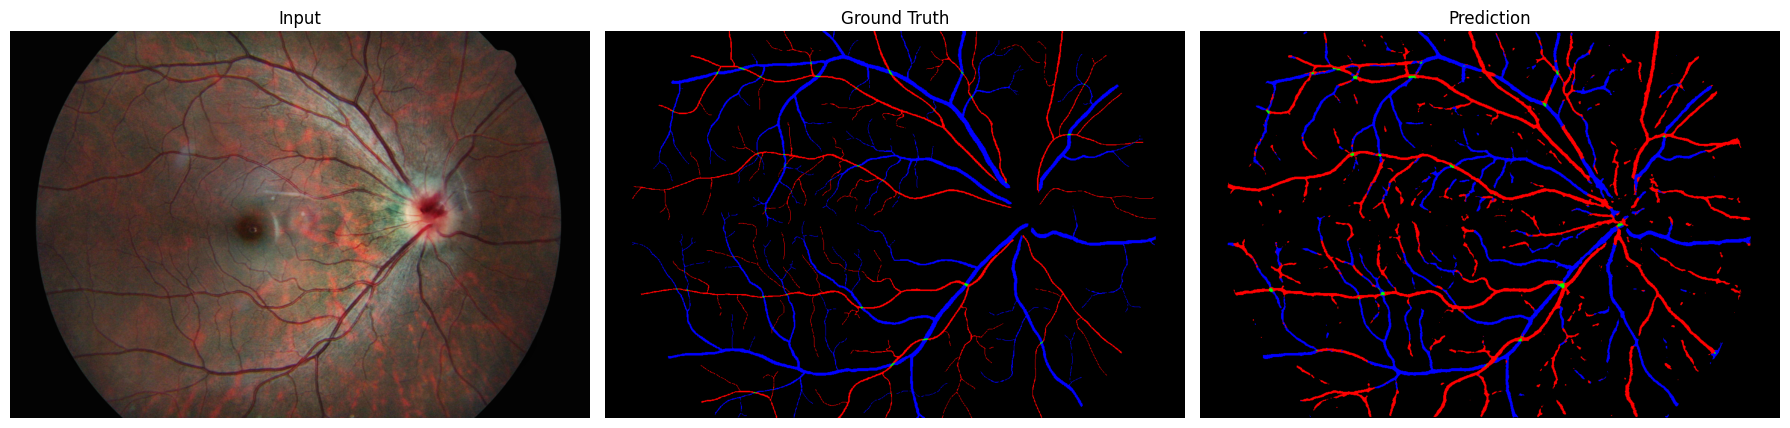

In [23]:
images, masks = next(iter(val_loader))
images = images.to(device)

with torch.no_grad():
    outputs = model(images)
    preds = torch.argmax(outputs, dim=1)

img = images[0].cpu().permute(1, 2, 0).numpy()
gt = masks[0].cpu().numpy()
pred = preds[0].cpu().numpy()

gt_rgb = mask_to_rgb(gt)
pred_rgb = mask_to_rgb(pred)

fig, ax = plt.subplots(1, 3, figsize=(18, 6))

ax[0].imshow(img)
ax[0].set_title("Input")

ax[1].imshow(gt_rgb)
ax[1].set_title("Ground Truth")

ax[2].imshow(pred_rgb)
ax[2].set_title("Prediction")

for a in ax:
    a.axis("off")

plt.tight_layout()
plt.show()

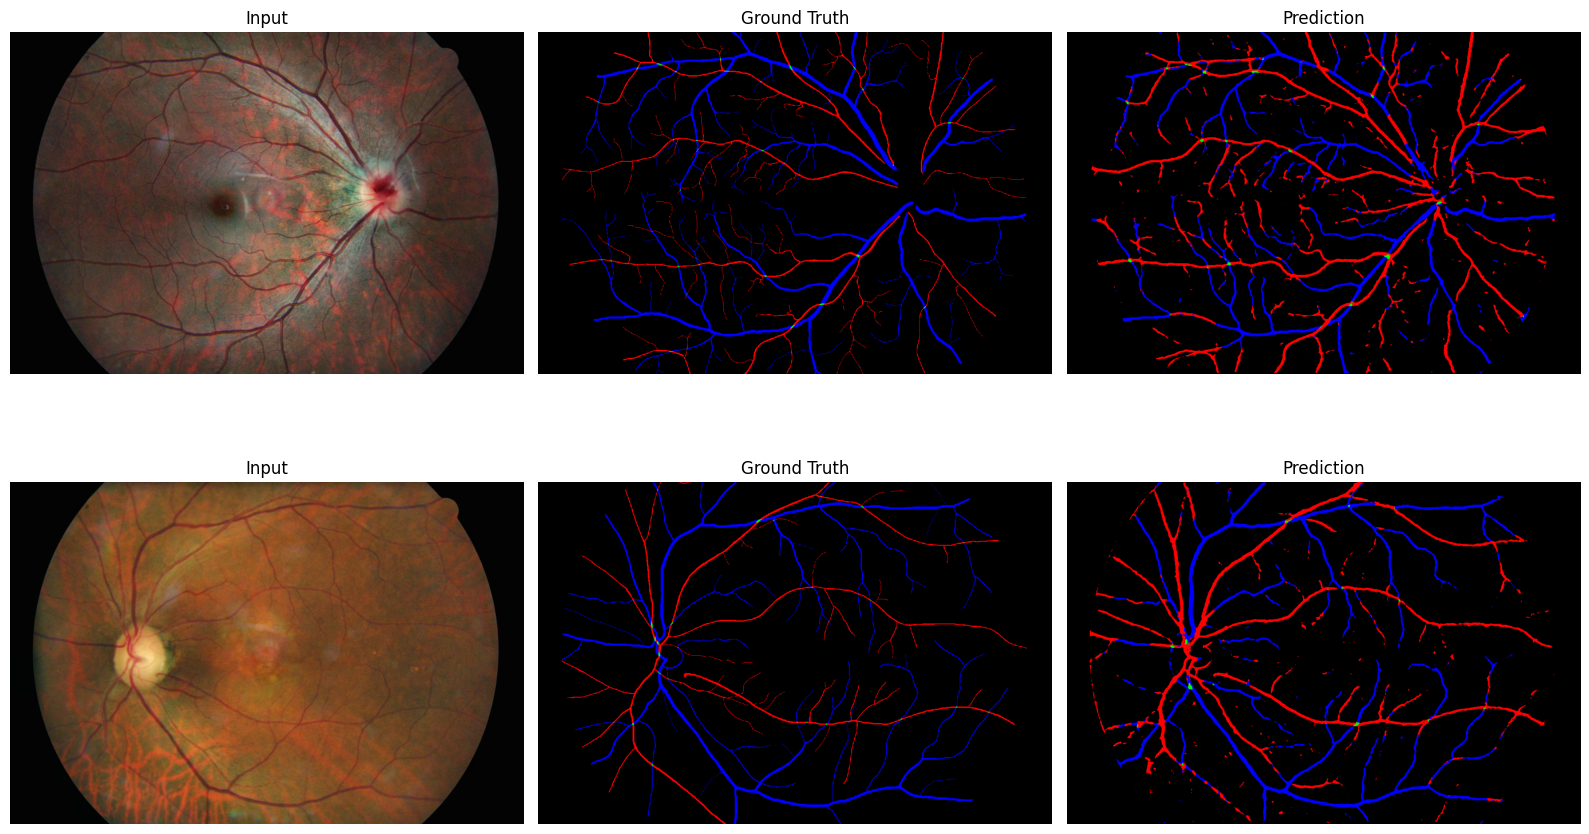

In [24]:
images, masks = next(iter(val_loader))
images = images.to(device)

with torch.no_grad():
    outputs = model(images)
    preds = torch.argmax(outputs, dim=1)

num_samples = images.shape[0]

fig, axes = plt.subplots(num_samples, 3, figsize=(16, 5*num_samples))

if num_samples == 1:
    axes = np.expand_dims(axes, axis=0)

for i in range(num_samples):
    img = images[i].cpu().permute(1, 2, 0).numpy()
    gt = masks[i].cpu().numpy()
    pred = preds[i].cpu().numpy()

    axes[i, 0].imshow(img)
    axes[i, 0].set_title("Input")

    axes[i, 1].imshow(mask_to_rgb(gt))
    axes[i, 1].set_title("Ground Truth")

    axes[i, 2].imshow(mask_to_rgb(pred))
    axes[i, 2].set_title("Prediction")

    for j in range(3):
        axes[i, j].axis("off")

plt.tight_layout()
plt.show()

In [25]:
def calculate_metrics(preds, targets, num_classes=4):
    preds = torch.argmax(preds, dim=1)

    metrics = {}

    precisions = []
    recalls = []
    f1s = []
    ious = []

    eps = 1e-7

    for cls in range(1, num_classes):
        pred_cls = (preds == cls).float()
        target_cls = (targets == cls).float()

        TP = (pred_cls * target_cls).sum()
        FP = (pred_cls * (1 - target_cls)).sum()
        FN = ((1 - pred_cls) * target_cls).sum()
        TN = ((1 - pred_cls) * (1 - target_cls)).sum()

        precision = TP / (TP + FP + eps)
        recall = TP / (TP + FN + eps)
        f1 = 2 * precision * recall / (precision + recall + eps)
        iou = TP / (TP + FP + FN + eps)
        specificity = TN / (TN + FP + eps)

        precisions.append(precision.item())
        recalls.append(recall.item())
        f1s.append(f1.item())
        ious.append(iou.item())

    metrics["precision"] = np.mean(precisions)
    metrics["recall"] = np.mean(recalls)
    metrics["f1"] = np.mean(f1s)
    metrics["iou"] = np.mean(ious)

    return metrics

In [26]:
with torch.no_grad():
    outputs = model(images)

metrics = calculate_metrics(outputs, masks)

print(metrics)

RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!

# Experiment 5: Final AV Segmentation Model (RGB + Augmentation + CE + Focal)

## Objective

Build a robust Artery Vein segmentation pipeline for retinal fundus images by improving upon previous experiments through:

1. Better preprocessing while preserving RGB information  
2. Data augmentation for generalization  
3. Improved loss function for class imbalance  
4. Better AV separation and vessel continuity  

---

# Dataset

Dataset structure:

```text
training/
├── images/
├── av/
└── masks/
```

### Inputs
Retinal Fundus Images

### Labels
AV masks with 4 classes:

- Class 0 → Background (Black)
- Class 1 → Artery (Red)
- Class 2 → Overlap / Crossing (Green)
- Class 3 → Vein (Blue)

---

# Model Architecture

Used:

## U-Net++

Encoder:
- EfficientNet-B2

Parameters:
- Input Channels = 3
- Output Classes = 4

Reason for selection:
- Strong encoder backbone
- Good multi-scale feature extraction
- Performs well in medical segmentation

---

# Data Split

Uniform split used:

- Train
- Validation
- Test

Split was saved using:

```python
dataset_split.pkl
```

This ensures consistent train validation test samples across experiments.

---

# Pipeline

Final pipeline:

```text
Fundus RGB
→ Augmentation
→ FOV Masking
→ RGB Channel Enhancement (CLAHE)
→ Normalization
→ U-Net++
→ CE + Focal Loss
```

---

# Preprocessing

## Step 1: FOV Masking

Removed irrelevant background pixels outside retinal region.

Purpose:
- Reduce unnecessary background noise
- Focus model only on retina region

---

## Step 2: RGB Channel-wise CLAHE

Applied CLAHE separately on:

- Red channel
- Green channel
- Blue channel

Code logic:

```python
r = clahe.apply(image[:,:,0])
g = clahe.apply(image[:,:,1])
b = clahe.apply(image[:,:,2])
```

Then reconstructed RGB image.

### Why this approach?

Earlier experiments used only green channel.

Problem:
- Lost artery vein color information

This improved:
- Vessel visibility
- Contrast
- AV color separation

---

## Step 3: Normalization

Scaled image values:

```python
image = image / 255.0
```

---

# Augmentation

Applied on training set only.

Used:

- Horizontal Flip
- Rotation
- Random Brightness Contrast

Purpose:
- Improve generalization
- Reduce overfitting
- Make model robust to variations

---

# Loss Function

Used combined loss:

## Weighted Cross Entropy + Focal Loss

---

## Why?

Problem in dataset:
- Severe class imbalance
- Background dominates
- Overlap pixels are extremely rare
- Thin vessels are difficult to segment

---

## Weighted Cross Entropy

Helps address class imbalance.

Weights used:

```python
[1.0, 10.0, 40.0, 10.0]
```

Meaning:
- Background gets lowest weight
- Overlap gets highest weight

---

## Focal Loss

Helps focus learning on:
- Hard pixels
- Minority classes
- Thin vessels

---

# Training

Training settings:

- Optimizer → Adam
- Learning Rate → 1e-4
- Batch Size → 2
- Epochs → 20

Reason batch size kept low:
- GPU memory stability

---

# Observations During Training

Training was stable.

No collapse unlike Dice Loss experiment.

Best validation performance observed around:

```text
Epoch 8
```

After that slight overfitting began.

---

# Results

## Positive Outcomes

### 1. Best model so far

This is currently the strongest pipeline among all experiments.

---

### 2. Major vessels segmented well

Strong segmentation for:
- Thick arteries
- Thick veins
- Optic disc branching region

---

### 3. RGB preprocessing improved AV classification

Compared to green-channel-only experiments:
- Better artery vein distinction
- Better vessel color preservation

---

### 4. Focal Loss improved class imbalance handling

Compared to CE only:
- Better minority class detection
- Better vessel continuity

---

# Problems Observed

---

## 1. Speckle Noise

Predictions contain small scattered false positives.

Observed as:
- Tiny red dots
- Tiny blue dots

Possible reason:
- High class weights
- Focal loss aggressively focusing on minority classes

---

## 2. Thin Vessel Detection Still Limited

Some capillaries are still missed.

Especially in peripheral regions.

---

## 3. Overlap Class Not Learned Well

Green overlap predictions are nearly absent.

Possible reasons:
- Overlap class is extremely rare
- Very difficult to learn

This remains a major challenge.

---

# Comparison with Previous Experiments

---

## Experiment 1: Raw RGB

Pipeline:

```text
Raw RGB → U-Net++
```

Result:
- Weak segmentation
- Poor vessel extraction

---

## Experiment 2: Green Channel + CLAHE

Pipeline:

```text
RGB → Green Channel → CLAHE → Model
```

Result:
- Good vessel segmentation
- Poor AV separation due to loss of color

---

## Experiment 3: CE + Dice Loss

Result:
- Cleaner vessel trees
- Better continuity
- Poor thin vessel detection
- Unstable training

---

## Experiment 5 (Current)

Pipeline:

```text
RGB + Augmentation + RGB CLAHE + CE + Focal
```

Result:
- Best overall performance so far

---

# Key Conclusions

---

## What Worked

- U-Net++
- RGB preprocessing
- CLAHE enhancement
- Data augmentation
- CE + Focal Loss

---

## Current Bottlenecks

Main issues are no longer architecture related.

Bottlenecks are:

1. Class imbalance  
2. Overlap class learning  
3. Thin vessel segmentation  
4. False positives  

---

# Next Possible Improvements

---

## Improvement 1

Reduce class weights:

From:

```python
[1, 10, 40, 10]
```

To:

```python
[1, 6, 20, 6]
```

Expected:
- Less speckle noise

---

## Improvement 2

Try 3-class segmentation instead of 4-class.

Classes:
- Background
- Artery
- Vein

Reason:
- Overlap class may be hurting training

---

## Improvement 3

Use stronger evaluation metrics:

- Dice Score
- IoU
- Sensitivity
- Specificity
- Per-class Dice

Not only accuracy.

---

# Final Conclusion

This experiment produced the best segmentation performance so far.

The pipeline is strong and reliable.

Main future improvements should focus on:
- Better class handling
- Better label strategy
- Loss tuning

Architecture is no longer the primary bottleneck.